In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from src.utils.data_processing import load_data_base
from src.utils.nlp_processing import text_clean

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/tiphainell/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/tiphainell/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/tiphainell/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
#Notebook qui permet d'explorer la colonne ClaimDescription du point de vue NLP : fréquence des mots, mots avec les plus grosses claims

In [3]:
dossier="/home/tiphainell/Documents/5.Direct Assurance/actuarial-loss-estimation"
database=load_data_base(dossier)
database=database[database['role']=='train']

In [4]:
#on homogénéise la claim en prenant les racines des mots
database['ClaimDescriptionClean']=database['ClaimDescription'].apply(lambda x:' '.join(text_clean(x)))

# database["ClaimDescriptionClean"] = database["ClaimDescriptionClean"].str.replace(
#     r"\b(right|left)\b",
#     "",
#     regex=True,
#     case=False
# )

In [5]:
#on tokénise avec nltk
corpus = database['ClaimDescriptionClean']
lst_tokens = nltk.tokenize.word_tokenize(corpus.str.cat(sep=" "))



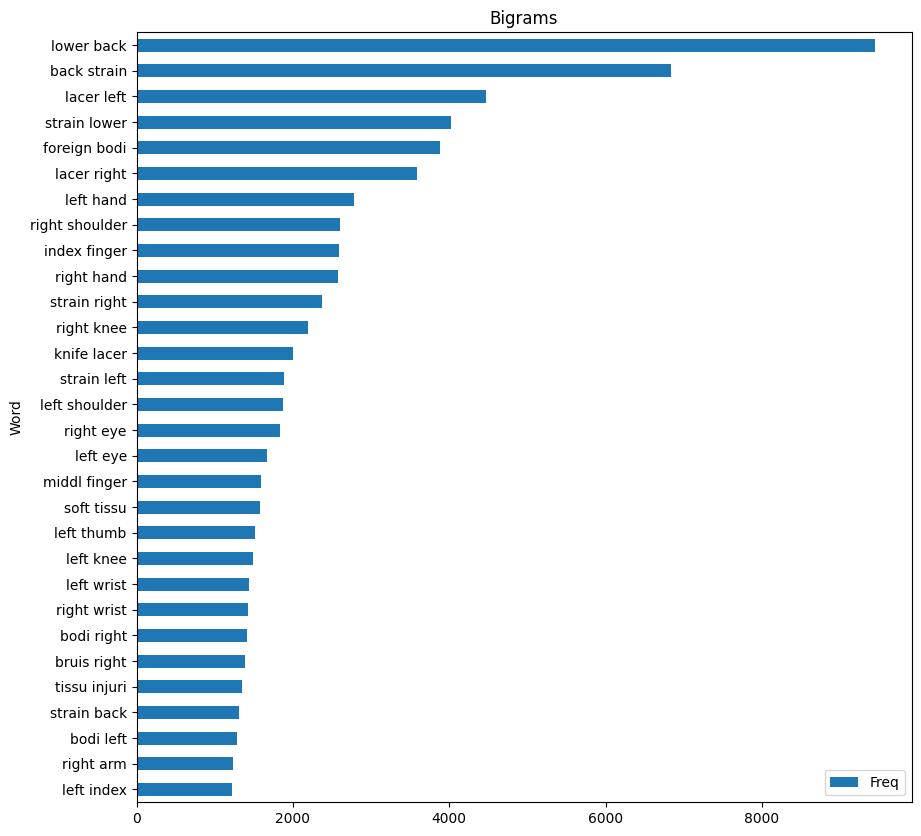

In [6]:
#Bigrams par fréquence
plt.figsize=((25,30))


dic_words_freq = nltk.FreqDist(nltk.ngrams(lst_tokens, 2))
dtf_bi = pd.DataFrame(dic_words_freq.most_common(), 
                      columns=["Word","Freq"])
dtf_bi["Word"] = dtf_bi["Word"].apply(lambda x: " ".join(
                   string for string in x) )
dtf_bi.set_index("Word").iloc[:30,:].sort_values(by="Freq").plot(kind="barh",figsize=(10,10))
plt.title('Bigrams')
                  
plt.show()

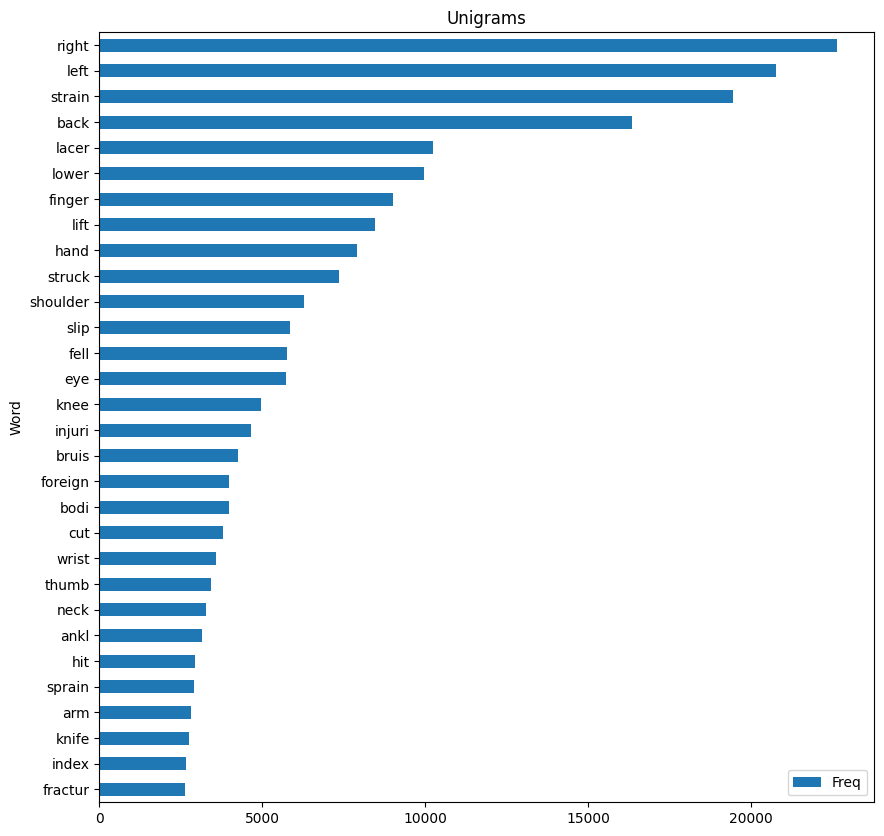

In [7]:
# single words that frequently occur in claim descr.

plt.figsize=((25,30))
dic_words_freq = nltk.FreqDist(nltk.ngrams(lst_tokens, 1))
dtf_bi = pd.DataFrame(dic_words_freq.most_common(), 
                      columns=["Word","Freq"])
dtf_bi["Word"] = dtf_bi["Word"].apply(lambda x: " ".join(
                   string for string in x) )
dtf_bi.set_index("Word").iloc[:30,:].sort_values(by="Freq").plot(kind="barh",figsize=(10,10))
plt.title('Unigrams')
                  
plt.show()



<Axes: ylabel='tokens'>

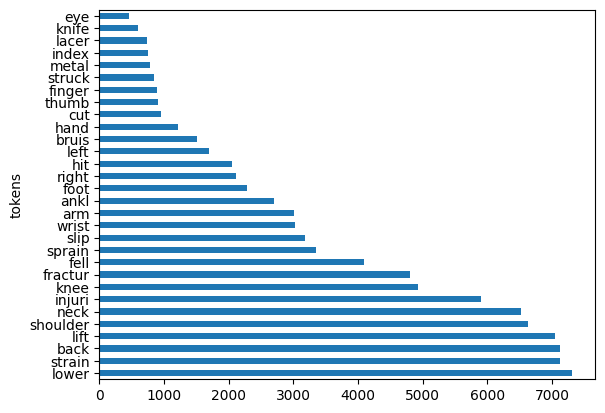

In [8]:
#One gram en focntion de la claim médiane
database["tokens"] = database["ClaimDescriptionClean"].apply(nltk.word_tokenize)
df_exploded = database[["tokens", "UltimateIncurredClaimCost"]].explode("tokens")
df_exploded["log_claim"] = np.log1p(df_exploded["UltimateIncurredClaimCost"])
word_mean_claim = df_exploded.groupby("tokens")["UltimateIncurredClaimCost"].median()
word_stats = df_exploded.groupby("tokens").agg(
    mean_claim=("UltimateIncurredClaimCost", "median"),
    count=("UltimateIncurredClaimCost", "count")
)

word_stats = word_stats[word_stats["count"] > 2500]

word_stats.sort_values("mean_claim", ascending=False).head(30)["mean_claim"].plot(kind="barh")

In [9]:

database["ClaimDescriptionClean"] = database["ClaimDescriptionClean"].str.replace(
    r"\b(right|left)\b",
    "",
    regex=True,
    case=False
)
# 1. Tokenisation
database["tokens"] = database["ClaimDescriptionClean"].apply(nltk.word_tokenize)

# 2. Création des bigrams
database["bigrams"] = database["tokens"].apply(lambda x: list(ngrams(x, 2)))

# 3. Explode (1 bigram = 1 ligne)
df_exploded = database[["bigrams", "UltimateIncurredClaimCost"]].explode("bigrams")

# 4. Drop NaN éventuels (important)
df_exploded = df_exploded.dropna(subset=["bigrams"])

# 5. Transform tuple -> string
df_exploded["bigrams"] = df_exploded["bigrams"].apply(lambda x: " ".join(x))

# 6. Log transform du claim
df_exploded["log_claim"] = np.log1p(df_exploded["UltimateIncurredClaimCost"])

# 7. Stats par bigram
word_stats = df_exploded.groupby("bigrams").agg(
    mean_claim=("log_claim", "mean"),
    count=("log_claim", "count")
)

# 8. Filtre fréquence (ajuste si besoin)
word_stats = word_stats[word_stats["count"] > 500]

# 9. Trier et plot
top_words = word_stats.sort_values("mean_claim", ascending=False).head(50)

top_words["mean_claim"].plot(kind="barh", figsize=(10,10))
plt.title("Top bigrams by mean log-claim")
plt.show()

NameError: name 'ngrams' is not defined

In [ ]:
database["is_left"] = database["ClaimDescriptionClean"].str.contains(r"\bleft\b", case=False, na=False).astype(int)

database["is_right"] = database["ClaimDescriptionClean"].str.contains(r"\bright\b", case=False, na=False).astype(int)

In [10]:
database.groupby("is_left")["UltimateIncurredClaimCost"].mean()

KeyError: 'is_left'

In [11]:
database.groupby("is_right")["UltimateIncurredClaimCost"].mean()

KeyError: 'is_right'